In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('u.data', sep='\t', names=['user_id','item_id','rating','timestamp'])
data.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [6]:
user_item_matrix = data.pivot(index='user_id', columns='item_id', values='rating')
user_item_matrix.fillna(0, inplace=True)

In [7]:
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity)

In [9]:
similar_users = user_similarity_df[0].sort_values(ascending=False)[1:6]
similar_users

,0
915,0.569066
863,0.547548
267,0.542077
91,0.540534
434,0.538665


In [8]:
predicted_ratings = np.dot(user_similarity, user_item_matrix) / np.array([np.abs(user_similarity).sum(axis=1)]).T

In [10]:
user_id = 1
user_predictions = predicted_ratings[user_id]
recommended_items = np.argsort(user_predictions)[-10:]
recommended_items

array([287,   0, 312, 299, 126, 180, 285, 257,  99,  49])

In [11]:
rmse = np.sqrt(mean_squared_error(user_item_matrix.values.flatten(), predicted_ratings.flatten()))
mae = mean_absolute_error(user_item_matrix.values.flatten(), predicted_ratings.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.7953288232879234
MAE: 0.3606215174267492


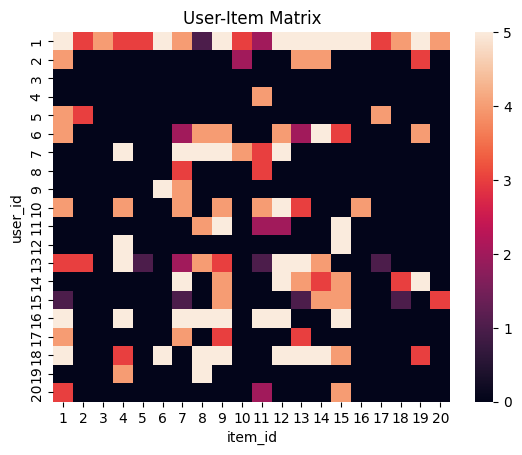

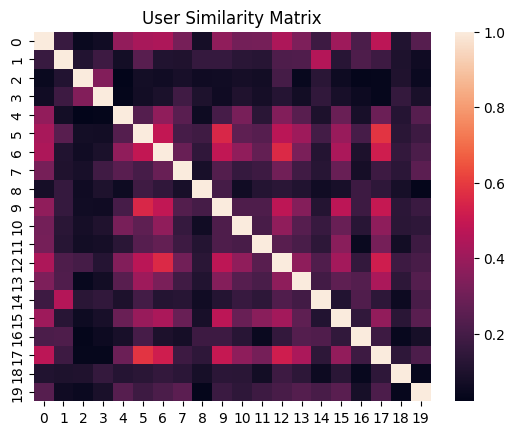

In [12]:
sns.heatmap(user_item_matrix.iloc[:20,:20])
plt.title("User-Item Matrix")
plt.show()

sns.heatmap(user_similarity_df.iloc[:20,:20])
plt.title("User Similarity Matrix")
plt.show()